In [ ]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import webbrowser

import KnnColorFunctions as Knnfcn

## Image Preprocessing 

# 1) Original Image Pixel compression

As K-means models typically runs in O(n * k * d) time complexity, where:

    n is the number of samples,

    k is the number of clusters,

    d is the number of dimensions (features) of each data point.

We have that a reduction of sample number by means of compression can lower the computational time by a factor of 1/n.

Thus we choose to compress the image to 200x200 pixels, still retaining the main needed information - that is, the color of the image.

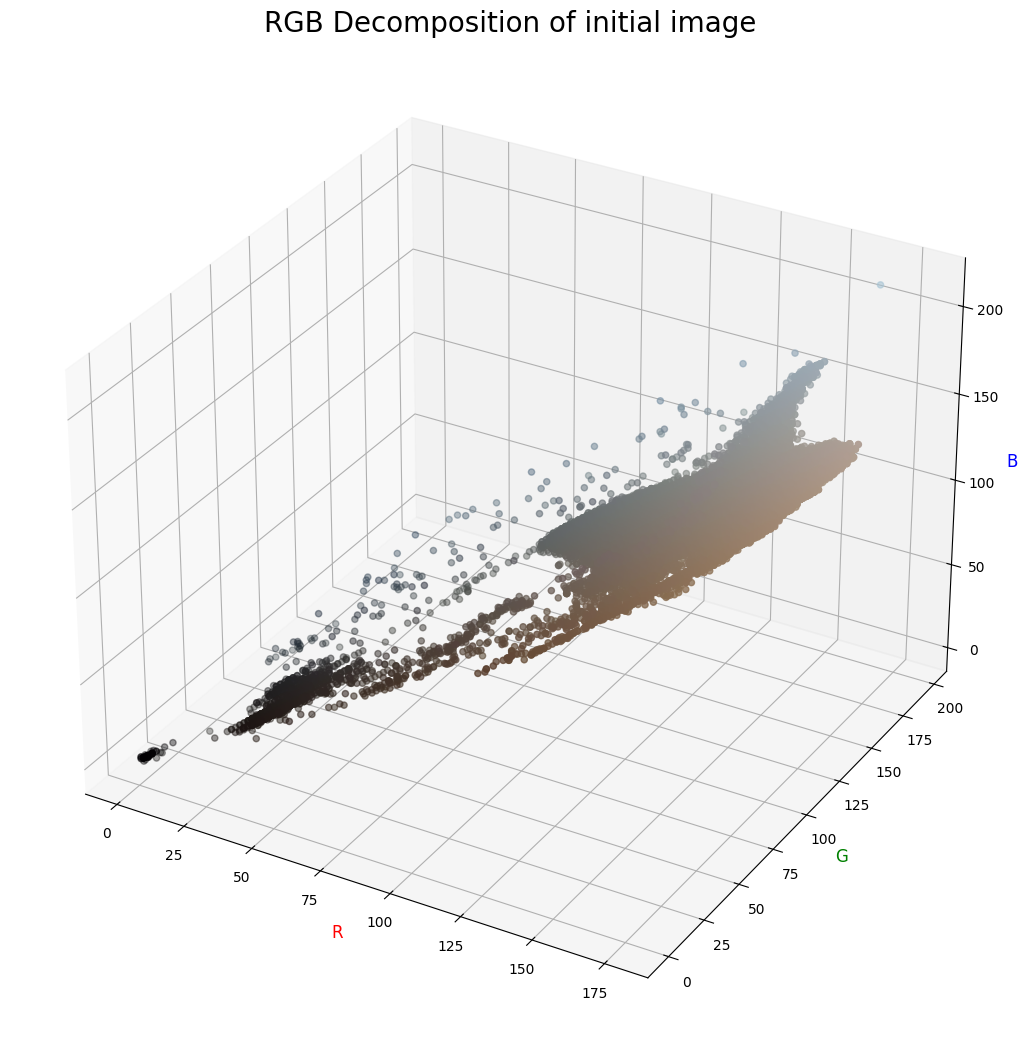

In [2]:
image_path = 'data/20250327_171942.jpg'

reshaped_image=Knnfcn.reshape_image(image_path)
decomposed_reshaped_image_3dplot = Knnfcn.reshaped_image_3d_plot(image_path)

## K-Means Model

Exploratory analysis: we choose a max number of 10 K-means centroids and we evaluate the inertia of the chosen clusters and their silhouette values; this should give us an idea of how the data in the image is distributed and what is the approximate best value for k

^ inertia increases because our image has a range of color that is not compressed; that means, we would have a spectrum of color to approximate this model properly. It can be speculated that after a given high number of k we could have an elbow (and thus a silhouette maximum after k = 2)

In [3]:
k_index,centroids_k,labels_k,k_inertia,silhouette_k = Knnfcn.KMeans_models(reshaped_image)

Processing cycle with 2 centroids, out of a max of 5
Processing cycle with 3 centroids, out of a max of 5
Processing cycle with 4 centroids, out of a max of 5
Processing cycle with 5 centroids, out of a max of 5


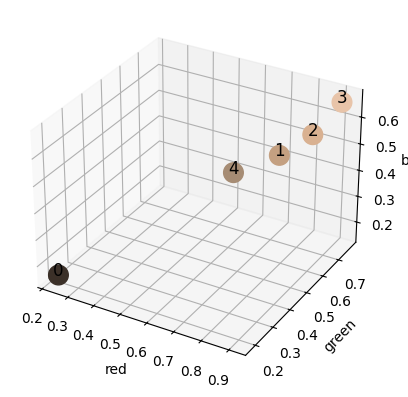

In [ ]:
max_centroids = centroids_k[-1]
red_centroid=[]
green_centroid=[]
blue_centroid=[]
for k in range(len(max_centroids)):
    red_centroid.append(max_centroids[k][0])
    green_centroid.append(max_centroids[k][1])
    blue_centroid.append(max_centroids[k][2])

red2=np.array(red_centroid)
green2=np.array(green_centroid)
blue2=np.array(blue_centroid)


fig4 = plt.figure()
ax = fig4.add_subplot(111, projection='3d')

ax.scatter(red2, green2, blue2,c=np.stack((red2, green2, blue2), axis=-1),s=200, marker='o',alpha=1)

for i in range(len(red2)):
    ax.text(red2[i], green2[i], blue2[i], f'{i}', color='black', fontsize=12, ha='center')

ax.set_xlabel('red')
ax.set_ylabel('green')
ax.set_zlabel('blue')

plt.show()
plt.close()

In [5]:
red_array,green_array,blue_array = Knnfcn.colors_k_centroids_all (centroids_k)
centroid_k_main_index,percentage_counts_k,k_main_color_list = Knnfcn.three_main_centroids_colors(labels_k,red_array,green_array,blue_array)

/tmp/ipykernel_84752/2229231993.py:5: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(red_array[i], green_array[i], blue_array[i],c=np.stack((red_array[i], green_array[i], blue_array[i]), axis=-1),s=200, marker='o',alpha=0.5)


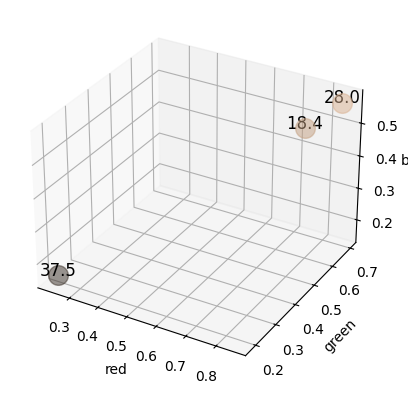

In [6]:


fig5 = plt.figure()
ax = fig5.add_subplot(111, projection='3d')

for i in centroid_k_main_index:
    ax.scatter(red_array[i], green_array[i], blue_array[i],c=np.stack((red_array[i], green_array[i], blue_array[i]), axis=-1),s=200, marker='o',alpha=0.5)

    ax.text(red_array[i], green_array[i], blue_array[i], f'{percentage_counts_k[i]}', color='black', fontsize=12, ha='center')

ax.set_xlabel('red')
ax.set_ylabel('green')
ax.set_zlabel('blue')


plt.show()

In [7]:
Knnfcn.create_color_rectangle_centroid(k_main_color_list,percentage_counts_k)

'images created'

In [8]:
colors = Knnfcn.three_main_centroids_colors(labels_k,red_array,green_array,blue_array)


main_1 = colors[2][0][0]
main_2 = colors[2][1][0]
main_3 = colors[2][2][0]

print(Knnfcn.classify_RAL(main_1))
print(Knnfcn.classify_RAL(main_2))
print(Knnfcn.classify_RAL(main_3))

(array(['RAL 6022'], dtype=object), 'Olive drab')
(array(['RAL 1001'], dtype=object), 'Beige')
(array(['RAL 1001'], dtype=object), 'Beige')


In [ ]:

url = Knnfcn.return_product_URL(Knnfcn.classify_RAL(main_2)[0],Knnfcn.classify_RAL(main_2)[1])
webbrowser.open(url)

[16584:13592:0413/192311.376:ERROR:interface_endpoint_client.cc(725)] Message 0 rejected by interface blink.mojom.WidgetHost


True